In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

pd.set_option('display.max_columns',None)

from sklearn.model_selection import train_test_split

import optuna
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
data = pd.read_excel(r"C:\Users\TOSHIBA\Downloads\data_main.xlsx")
data.head()

,Contracts,target,GENDER,Region,90_dpd_crd_max,contract_over_request_cnt_9,app_phone_amount_06_count,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount
0,074485ec63,0,F,Ganja-Qazakh,0.0,0.000000,0.0,0.0,46,80000,26740,167993,456,2,2,7.96,24,0.15,Bachelor's,Unemployed,Divorced,No,Education,0
1,7aecfd8ce6,0,F,Baku,0.0,0.000000,2.0,1.0,39,390000,93963,69696,505,79,1,5.57,24,0.51,Bachelor's,Self-employed,Divorced,No,Business,258
2,50933072e5,0,F,Ganja-Qazakh,0.0,0.033333,0.0,0.0,64,70000,69935,226921,765,114,4,8.70,36,0.57,High School,Self-employed,Married,No,Education,0
3,36ffd9fda8,0,M,Aran,0.0,0.500000,0.0,0.0,57,230000,148476,41087,814,54,1,12.62,60,0.16,High School,Self-employed,Married,Yes,Home,0
4,c0b46bdbdb,0,F,Ganja-Qazakh,0.0,0.083333,0.0,0.0,50,130000,84072,66095,621,92,4,17.27,36,0.73,Bachelor's,Full-time,Single,Yes,Auto,0


In [4]:
data.describe(include='all')

,Contracts,target,GENDER,Region,90_dpd_crd_max,contract_over_request_cnt_9,app_phone_amount_06_count,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount
count,13206,13206.000000,13206,13206,13206.000000,13206.000000,13062.000000,13051.000000,13206.000000,13206.000000,13206.000000,13206.000000,13206.000000,13206.000000,13206.000000,13166.000000,13206.000000,13206.000000,13206,13206,13109,13206,13206,13206.000000
unique,13206,NaN,2,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,3,2,5,NaN
top,074485ec63,NaN,M,Baku,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High School,Unemployed,Married,No,Home,NaN
freq,1,NaN,6927,3619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3336,3373,4433,6627,2695,NaN
mean,NaN,0.036499,NaN,NaN,45.023542,0.144771,0.748507,5.436901,39.256399,167466.000303,82705.986067,127819.831213,574.713312,59.464562,2.494927,13.492304,36.027260,0.504169,NaN,NaN,NaN,NaN,NaN,317.126761
std,NaN,0.187534,NaN,NaN,547.412411,0.367933,2.585893,6.146567,11.198711,129331.435026,38801.098371,71075.961507,158.928163,34.571931,1.111339,6.637123,16.998149,0.231284,NaN,NaN,NaN,NaN,NaN,334.796923
min,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,18.000000,10000.000000,15003.000000,5006.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,30.000000,50000.000000,48872.500000,66180.500000,437.000000,30.000000,2.000000,7.810000,24.000000,0.300000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,0.000000,NaN,NaN,0.000000,0.033333,0.000000,3.000000,38.000000,140000.000000,82512.500000,128827.500000,576.000000,59.000000,2.000000,13.400000,36.000000,0.510000,NaN,NaN,NaN,NaN,NaN,211.000000
75%,NaN,0.000000,NaN,NaN,0.000000,0.105263,0.000000,9.000000,48.000000,240000.000000,116411.500000,189481.500000,714.000000,89.000000,3.000000,19.290000,48.000000,0.700000,NaN,NaN,NaN,NaN,NaN,610.000000


In [5]:
data.columns

Index(['Contracts', 'target', 'GENDER', 'Region', '90_dpd_crd_max',
       'contract_over_request_cnt_9', 'app_phone_amount_06_count',
       'online_pos_9_count', 'AGE', 'LIMIT_BAL', 'Income', 'LoanAmount',
       'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate',
       'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'LoanPurpose', 'online_pos_amount'],
      dtype='str')

In [6]:
data.drop(['Contracts','90_dpd_crd_max','app_phone_amount_06_count'], axis=1, inplace=True)

In [7]:
data.isnull().sum()

target                           0
GENDER                           0
Region                           0
contract_over_request_cnt_9      0
online_pos_9_count             155
AGE                              0
LIMIT_BAL                        0
Income                           0
LoanAmount                       0
CreditScore                      0
MonthsEmployed                   0
NumCreditLines                   0
InterestRate                    40
LoanTerm                         0
DTIRatio                         0
Education                        0
EmploymentType                   0
MaritalStatus                   97
HasMortgage                      0
LoanPurpose                      0
online_pos_amount                0
dtype: int64

### Logistic Regression
- Missing value treatment
- WoE
- Correlation

### KNN
- Missing value treatment
- Outlier
- Correlation
- VIF
- Conversion (pd.get_dummies)

### Random Forest
- Missing value treatment
- Conversion (Label Encoder)
### XGBoost
- Conversion (Label Encoder)
### Catboost
- Conversion (Label Encoder)
### Lightgbm
-Conversion (Label Encoder)
### Catboost categorical
- if missing in categorical variables fillna Missing Value

In [8]:
data_lr_knn_rf = data.copy()
data_xgb_cb_lgbm_cbc = data.copy()

In [9]:
for i in data_lr_knn_rf.columns:
    if i in ['online_pos_9_count']:
        data_lr_knn_rf[i]=data_lr_knn_rf[i].fillna(0)
    elif data_lr_knn_rf[i].dtype == 'str':
        data_lr_knn_rf[i]=data_lr_knn_rf[i].fillna(data_lr_knn_rf[i].mode()[0])
    else:
        data_lr_knn_rf[i]=data_lr_knn_rf[i].fillna(data_lr_knn_rf[i].mean())

In [10]:
data_lr_knn_rf.isnull().sum()

target                         0
GENDER                         0
Region                         0
contract_over_request_cnt_9    0
online_pos_9_count             0
AGE                            0
LIMIT_BAL                      0
Income                         0
LoanAmount                     0
CreditScore                    0
MonthsEmployed                 0
NumCreditLines                 0
InterestRate                   0
LoanTerm                       0
DTIRatio                       0
Education                      0
EmploymentType                 0
MaritalStatus                  0
HasMortgage                    0
LoanPurpose                    0
online_pos_amount              0
dtype: int64

In [11]:
data_lr = data_lr_knn_rf.copy()
data_knn = data_lr_knn_rf.copy()
data_rf = data_lr_knn_rf.copy()

## Logistic Regression

In [12]:
for var in data_lr.columns:
    if var == 'target':
        continue  

    if data_lr[var].dtypes != 'str':
        
        q1 = data_lr[var].quantile(0.25)
        q2 = data_lr[var].quantile(0.5)
        q3 = data_lr[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        data_lr['category_' + var] = pd.cut(data_lr[var], bins=ranges, duplicates='drop')

        grouped = data_lr.groupby(['category_' + var, 'target'])['target'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[['category_' + var, var + '_woe']], how='left', on='category_' + var)

    elif data_lr[var].dtypes == 'str':

        grouped = data_lr.groupby([var, 'target'])['target'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data_lr = data_lr.merge(grouped[[var, var + '_woe']], how='left', on=var)
        
data_lr

,target,GENDER,Region,contract_over_request_cnt_9,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount,GENDER_woe,Region_woe,category_contract_over_request_cnt_9,contract_over_request_cnt_9_woe,category_online_pos_9_count,online_pos_9_count_woe,category_AGE,AGE_woe,category_LIMIT_BAL,LIMIT_BAL_woe,category_Income,Income_woe,category_LoanAmount,LoanAmount_woe,category_CreditScore,CreditScore_woe,category_MonthsEmployed,MonthsEmployed_woe,category_NumCreditLines,NumCreditLines_woe,category_InterestRate,InterestRate_woe,category_LoanTerm,LoanTerm_woe,category_DTIRatio,DTIRatio_woe,Education_woe,EmploymentType_woe,MaritalStatus_woe,HasMortgage_woe,LoanPurpose_woe,category_online_pos_amount,online_pos_amount_woe
0,0,F,Ganja-Qazakh,0.000000,0.0,46,80000,26740,167993,456,2,2,7.96,24,0.15,Bachelor's,Unemployed,Divorced,No,Education,0,0.800841,-0.141106,"(-inf, 0.0]",0.539054,"(-inf, 0.0]",-0.048517,"(38.0, 48.0]",0.483632,"(50000.0, 140000.0]",0.003997,"(-inf, 48872.5]",0.013155,"(128827.5, 189481.5]",-0.094932,"(437.0, 576.0]",0.026608,"(-inf, 30.0]",0.061342,"(-inf, 2.0]",-0.006223,"(7.83, 13.43]",0.114849,"(-inf, 24.0]",-0.008325,"(-inf, 0.3]",-0.034780,0.088387,-0.103554,0.061314,0.029916,-0.068368,"(-inf, 0.0]",-0.048517
1,0,F,Baku,0.000000,1.0,39,390000,93963,69696,505,79,1,5.57,24,0.51,Bachelor's,Self-employed,Divorced,No,Business,258,0.800841,0.478610,"(-inf, 0.0]",0.539054,"(0.0, 3.0]",-0.455717,"(38.0, 48.0]",0.483632,"(240000.0, inf]",-0.095581,"(82512.5, 116411.5]",-0.126048,"(66180.5, 128827.5]",0.048288,"(437.0, 576.0]",0.026608,"(59.0, 89.0]",-0.060334,"(-inf, 2.0]",-0.006223,"(-inf, 7.83]",-0.045890,"(-inf, 24.0]",-0.008325,"(0.3, 0.51]",-0.102166,0.088387,0.038060,0.061314,0.029916,0.113678,"(211.0, 610.0]",0.063633
2,0,F,Ganja-Qazakh,0.033333,0.0,64,70000,69935,226921,765,114,4,8.70,36,0.57,High School,Self-employed,Married,No,Education,0,0.800841,-0.141106,"(0.0, 0.0333]",-0.250418,"(-inf, 0.0]",-0.048517,"(48.0, inf]",0.589532,"(50000.0, 140000.0]",0.003997,"(48872.5, 82512.5]",0.094308,"(189481.5, inf]",0.075976,"(714.0, inf]",0.071263,"(89.0, inf]",-0.069339,"(3.0, inf]",-0.086819,"(7.83, 13.43]",0.114849,"(24.0, 36.0]",0.079948,"(0.51, 0.7]",0.043526,-0.107357,0.038060,0.014780,0.029916,-0.068368,"(-inf, 0.0]",-0.048517
3,0,M,Aran,0.500000,0.0,57,230000,148476,41087,814,54,1,12.62,60,0.16,High School,Self-employed,Married,Yes,Home,0,-0.418326,-0.315429,"(0.105, inf]",-0.600455,"(-inf, 0.0]",-0.048517,"(48.0, inf]",0.589532,"(140000.0, 240000.0]",0.063242,"(116411.5, inf]",0.030732,"(-inf, 66180.5]",-0.021164,"(714.0, inf]",0.071263,"(30.0, 59.0]",0.076442,"(-inf, 2.0]",-0.006223,"(7.83, 13.43]",0.114849,"(48.0, inf]",-0.111433,"(-inf, 0.3]",-0.034780,-0.107357,0.038060,0.014780,-0.029318,0.036089,"(-inf, 0.0]",-0.048517
4,0,F,Ganja-Qazakh,0.083333,0.0,50,130000,84072,66095,621,92,4,17.27,36,0.73,Bachelor's,Full-time,Single,Yes,Auto,0,0.800841,-0.141106,"(0.0333, 0.105]",0.591872,"(-inf, 0.0]",-0.048517,"(48.0, inf]",0.589532,"(50000.0, 140000.0]",0.003997,"(82512.5, 116411.5]",-0.126048,"(-inf, 66180.5]",-0.021164,"(576.0, 714.0]",-0.143494,"(89.0, inf]",-0.069339,"(3.0, inf]",-0.086819,"(13.43, 19.27]",-0.095563,"(24.0, 36.0]",0.079948,"(0.7, inf]",0.112657,0.088387,-0.044156,-0.071411,-0.029318,0.027700,"(-inf, 0.0]",-0.048517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13201,0,F,Aran,0.125000,2.0,36,50000,37218,100093,363,16,2,24.49,60,0.66,High School,Self-employed,Single,No,Auto,790,0.800841,-0.315429,"(0.105, inf]",-0.600455,"(0.0, 3.0]",-0.455717,"(30.0, 38.0]",0.134183,"(-inf, 50000.0]",0.028122,"(-inf, 48872.5]",0.013155,"(66180.5, 128827.5]",0.048288,"(-inf, 437.0]",0.059530,"(-in

In [13]:
def target_correlation(data, target, threshold=0.01):
    
    woe_features = data.filter(regex='_woe$', axis=1) 
    woe_features[target] = data[target] 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target


target_result = target_correlation(data_lr, 'target')

target_result

,Variable,Correlation with Target
0,GENDER_woe,-0.100404
1,Region_woe,-0.061604
2,contract_over_request_cnt_9_woe,-0.092901
3,online_pos_9_count_woe,-0.051852
4,AGE_woe,-0.091705
5,LIMIT_BAL_woe,-0.010427
6,Income_woe,-0.014447
7,LoanAmount_woe,-0.012293
8,CreditScore_woe,-0.014632
9,MonthsEmployed_woe,-0.011676


In [14]:
def intercorrelation(data, target, threshold=0.7):
    
    woe_features = data.filter(regex='_woe$', axis=1) 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    correlated_pairs_set = set()
   
    for var1, var2 in zip(independent_variable_pairs[0], independent_variable_pairs[1]):

        if var1 < var2:
            correlated_pairs_set.add((corr_matrix.index[var1], corr_matrix.columns[var2]))
        else:
            correlated_pairs_set.add((corr_matrix.index[var2], corr_matrix.columns[var1]))
            
   # print(correlated_pairs_set)
    
    result_intercorrelated_independent = pd.DataFrame(list(correlated_pairs_set), columns=['Variable 1', 'Variable 2'])
    
    return result_intercorrelated_independent

# Example usage
intercorrelated_result = intercorrelation(data_lr, 'target')
intercorrelated_result


,Variable 1,Variable 2


In [15]:
LR_vars = target_result.Variable.tolist()

LR_vars # variables for Logistic Regression

['GENDER_woe',
 'Region_woe',
 'contract_over_request_cnt_9_woe',
 'online_pos_9_count_woe',
 'AGE_woe',
 'LIMIT_BAL_woe',
 'Income_woe',
 'LoanAmount_woe',
 'CreditScore_woe',
 'MonthsEmployed_woe',
 'NumCreditLines_woe',
 'InterestRate_woe',
 'LoanTerm_woe',
 'DTIRatio_woe',
 'Education_woe',
 'EmploymentType_woe',
 'MaritalStatus_woe',
 'LoanPurpose_woe',
 'online_pos_amount_woe']

### KNN

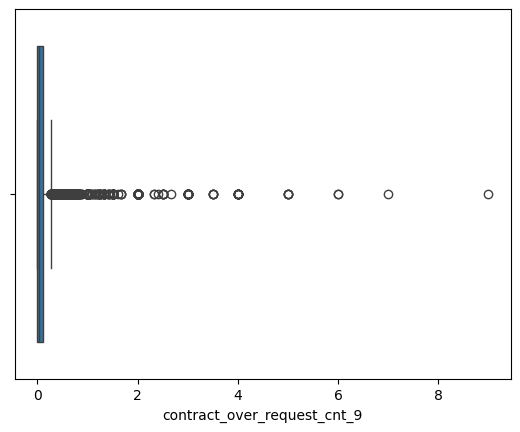

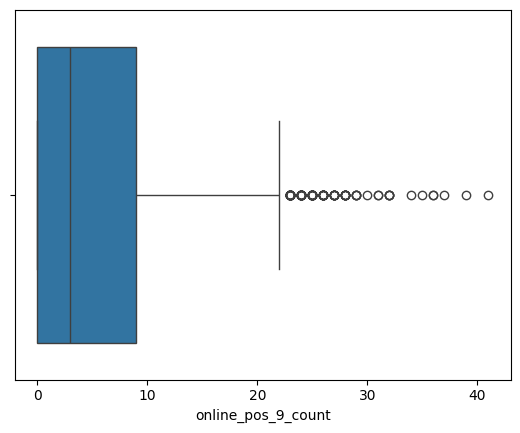

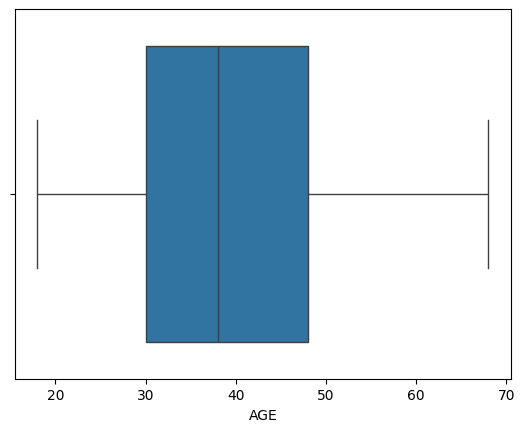

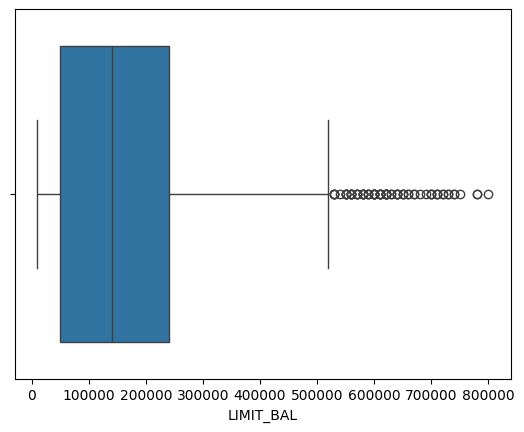

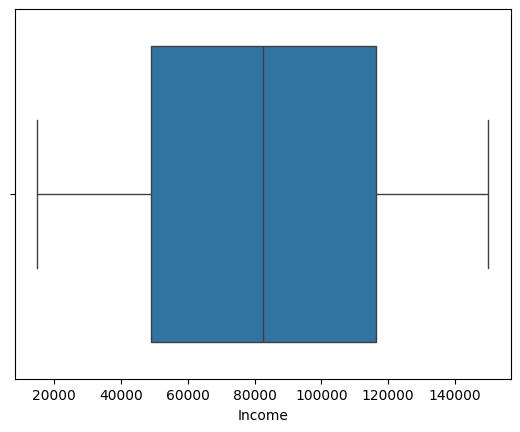

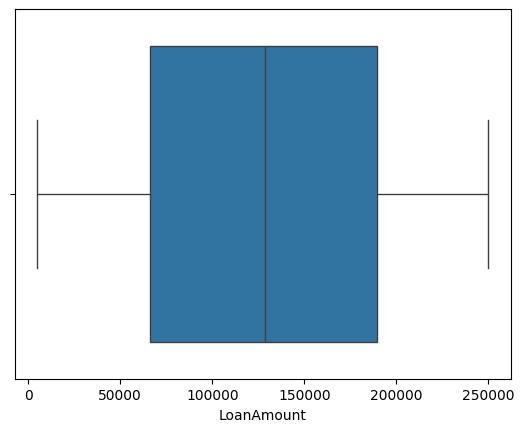

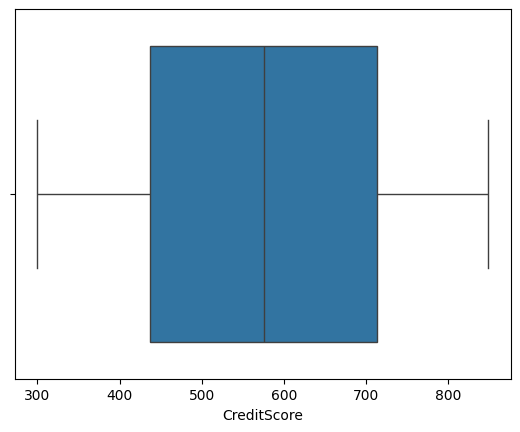

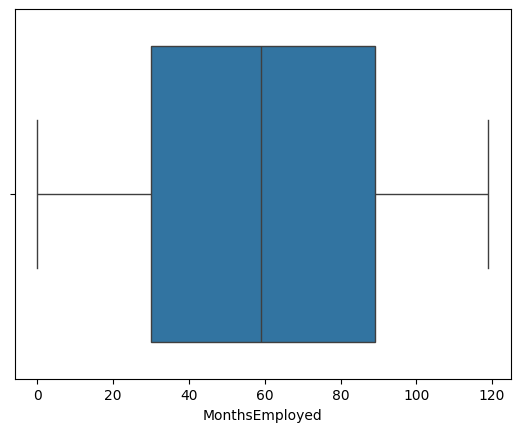

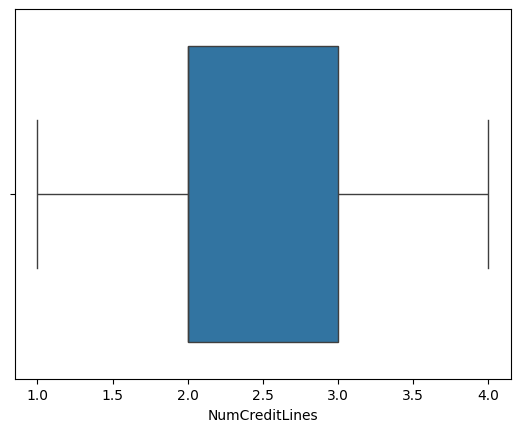

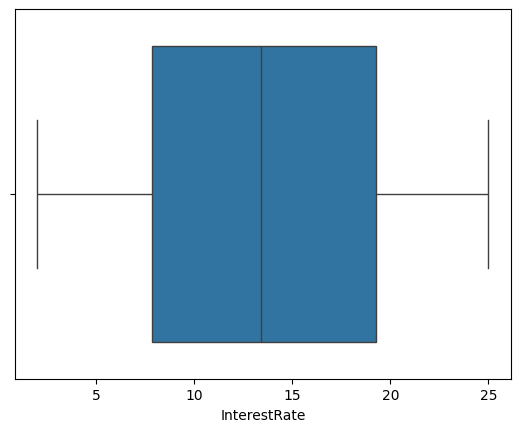

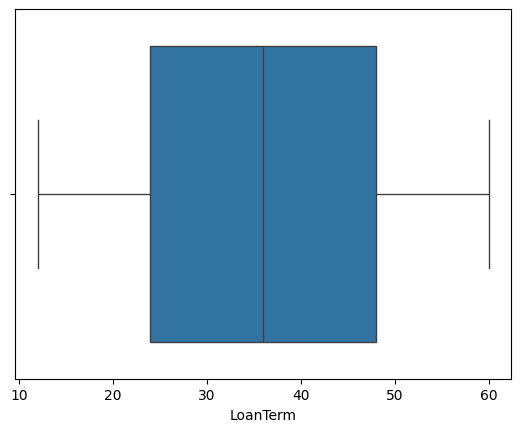

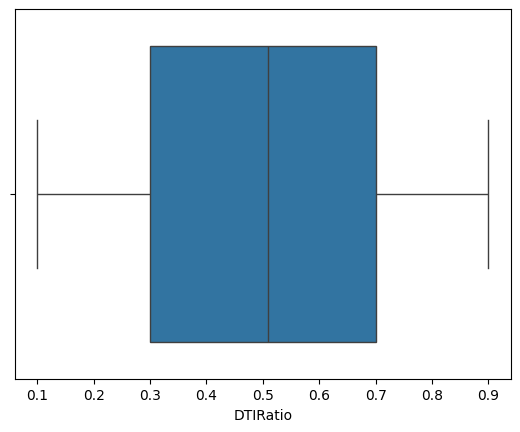

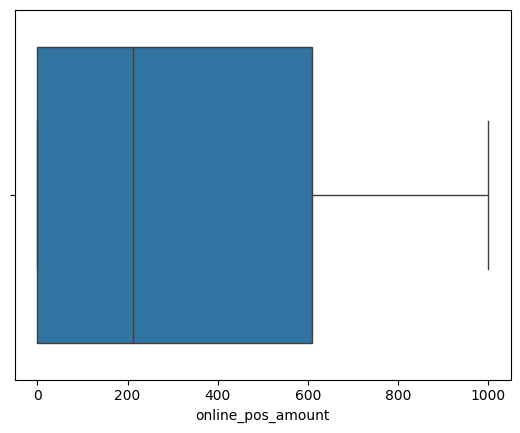

In [16]:
for i in data_knn.columns:
    if data_knn[i].dtypes!='str' and i!='target':
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [17]:
q1=data_knn.quantile(0.25, numeric_only=True)
q3=data_knn.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

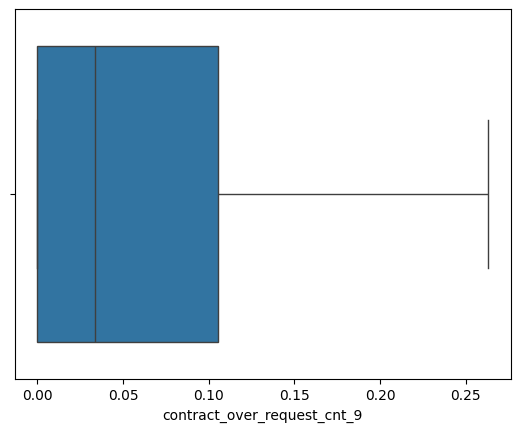

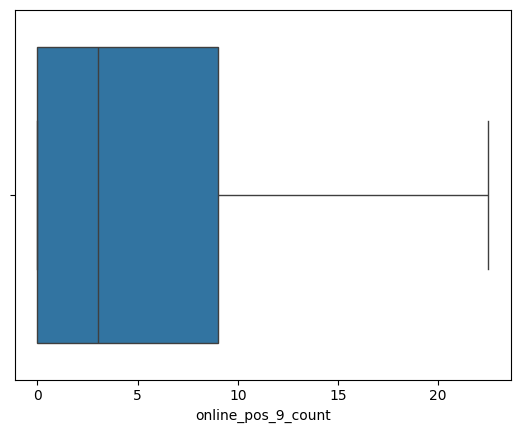

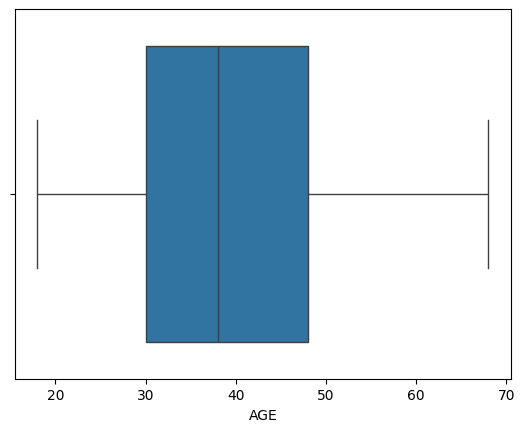

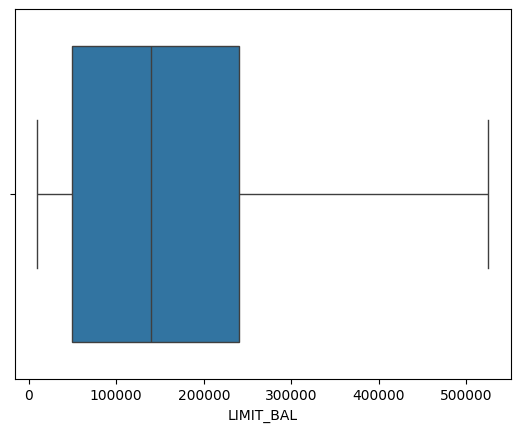

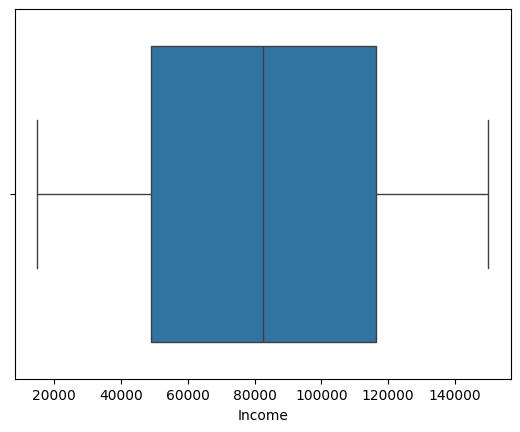

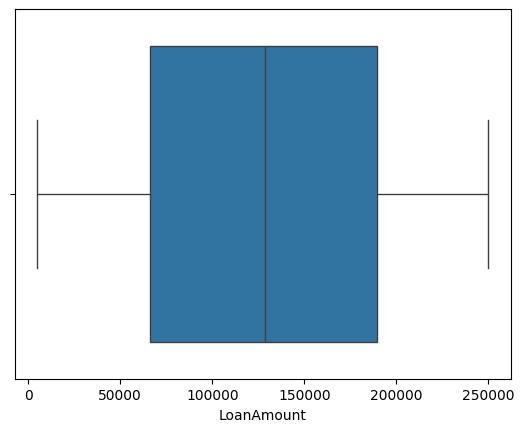

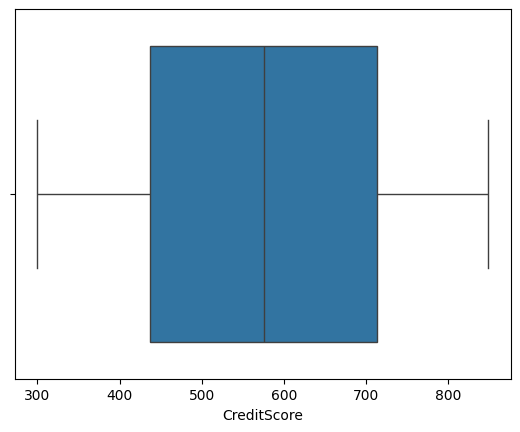

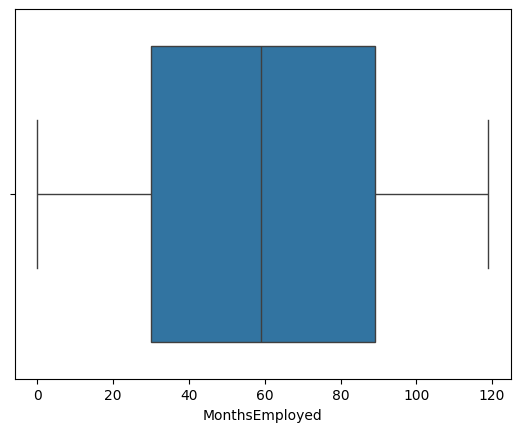

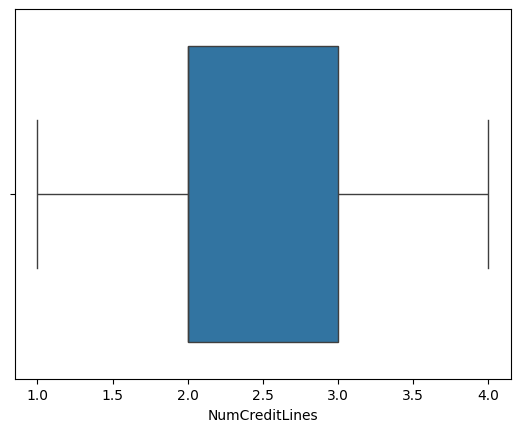

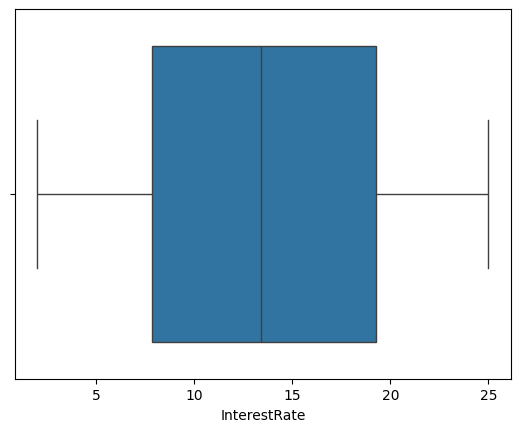

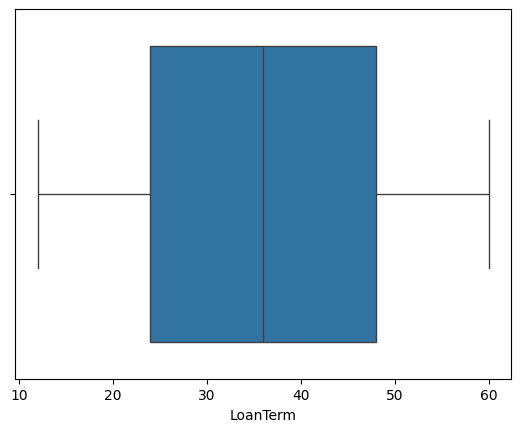

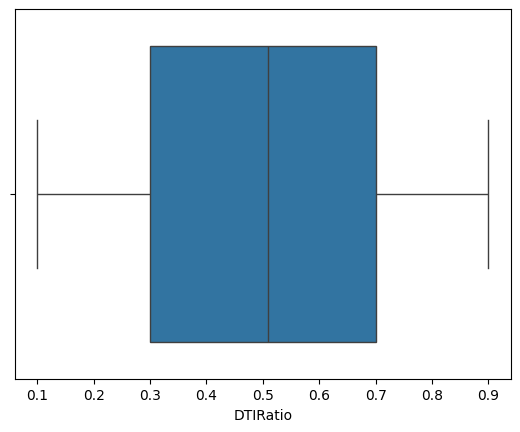

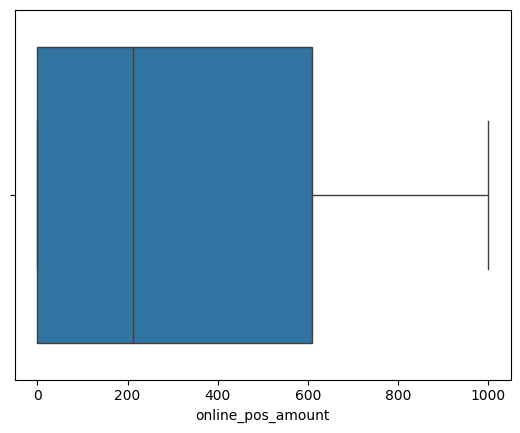

In [18]:
for i in data_knn.columns:
    if data_knn[i].dtypes!='str' and i!='target':
        data_knn[i] = np.where(data_knn[i] > Upper[i],Upper[i],data_knn[i])
        data_knn[i] = np.where(data_knn[i] < Lower[i],Lower[i],data_knn[i])
        sns.boxplot(data=data_knn,x=data_knn[i])
        plt.show()

In [19]:
def target_correlation(data, target, threshold=0.01):
    corr_matrix = data.corr(method='spearman', numeric_only=True)
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target

target_result = target_correlation(data_knn, 'target')

target_result

,Variable,Correlation with Target
0,contract_over_request_cnt_9,0.082781
1,online_pos_9_count,-0.034448
2,AGE,-0.094179
3,MonthsEmployed,0.013454
4,DTIRatio,-0.014003


In [20]:
def intercorrelation(data, target, threshold=0.7):
    corr_matrix = data.drop(columns=[target]).corr(method='spearman', numeric_only=True)
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    result_intercorrelated_independent = pd.DataFrame({
        'Variable 1': corr_matrix.index[independent_variable_pairs[0]],
        'Variable 2': corr_matrix.columns[independent_variable_pairs[1]]
    })
    return result_intercorrelated_independent

intercorrelated_result = intercorrelation(data_knn, 'target')

intercorrelated_result

,Variable 1,Variable 2
0,online_pos_9_count,online_pos_amount
1,online_pos_amount,online_pos_9_count


In [21]:
target_result.Variable.tolist()

['contract_over_request_cnt_9',
 'online_pos_9_count',
 'AGE',
 'MonthsEmployed',
 'DTIRatio']

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, variables):
    vif_data = data[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data_knn, [
                                           'contract_over_request_cnt_9',
 'online_pos_9_count',
 #'AGE',
 'MonthsEmployed',
 'DTIRatio'
 
                                        ])

vif_result


,VIF,Features
0,1.512800,contract_over_request_cnt_9
1,1.651347,online_pos_9_count
2,2.833536,MonthsEmployed
3,3.102667,DTIRatio


In [23]:
vif_result.Features.tolist()

['contract_over_request_cnt_9',
 'online_pos_9_count',
 'MonthsEmployed',
 'DTIRatio']

In [24]:
for i in data_knn.columns:
    if data_knn[i].dtypes=='str':
        print(data_knn[i].value_counts())

GENDER
M    6927
F    6279
Name: count, dtype: int64
Region
Baku               3619
Aran               2917
Ganja-Qazakh       1579
Yukhari Qarabag    1144
Absheron            848
Shaki-Zagatala      824
Nakhchivan          761
Lankaran            668
Daqlig Shirvan      436
Quba-Khachmaz       410
Name: count, dtype: int64
Education
High School    3336
PhD            3334
Bachelor's     3312
Master's       3224
Name: count, dtype: int64
EmploymentType
Unemployed       3373
Self-employed    3297
Part-time        3280
Full-time        3256
Name: count, dtype: int64
MaritalStatus
Married     4530
Single      4374
Divorced    4302
Name: count, dtype: int64
HasMortgage
No     6627
Yes    6579
Name: count, dtype: int64
LoanPurpose
Home         2695
Education    2668
Other        2627
Auto         2617
Business     2599
Name: count, dtype: int64


In [25]:
segment_mapping_education = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3
}
data_knn["Education"] = data_knn["Education"].map(segment_mapping_education)

segment_mapping_emp = {
    "Unemployed": 0,
    "Self-employed": 1,
    "Part-time":2,
    "Full-time":3
}
data_knn["EmploymentType"] = data_knn["EmploymentType"].map(segment_mapping_emp)


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for i in data_knn.columns:
    data_knn[i] = le.fit_transform(data_knn[i])
data_knn

,target,GENDER,Region,contract_over_request_cnt_9,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount
0,0,0,4,0,0,28,8,1034,8524,156,2,1,592,1,5,1,0,0,0,2,0
1,0,0,2,0,1,21,39,7352,3388,205,79,0,356,1,41,1,1,0,0,1,249
2,0,0,4,57,0,46,7,5069,11624,465,114,3,666,2,47,0,1,1,0,2,0
3,0,1,1,234,0,39,23,12443,1953,514,54,0,1057,4,6,0,1,1,1,3,0
4,0,0,4,128,0,32,13,6438,3221,321,92,3,1523,2,63,1,3,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13201,0,0,1,168,2,18,5,2061,4996,63,16,1,2243,4,56,0,1,2,0,0,781
13202,0,0,1,0,8,19,12,12454,1600,87,48,1,1515,2,41,0,0,0,0,0,156
13203,0,0,7,80,6,20,20,9604,7919,74,51,2,686,1,22,2,0,0,1,3,218
13204,0,1,6,0,9,19,20,2386,4777,94,39,3,15,4,6,0,0,2,1,1,507


### Random Forest

In [27]:
data_rf

,target,GENDER,Region,contract_over_request_cnt_9,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount
0,0,F,Ganja-Qazakh,0.000000,0.0,46,80000,26740,167993,456,2,2,7.96,24,0.15,Bachelor's,Unemployed,Divorced,No,Education,0
1,0,F,Baku,0.000000,1.0,39,390000,93963,69696,505,79,1,5.57,24,0.51,Bachelor's,Self-employed,Divorced,No,Business,258
2,0,F,Ganja-Qazakh,0.033333,0.0,64,70000,69935,226921,765,114,4,8.70,36,0.57,High School,Self-employed,Married,No,Education,0
3,0,M,Aran,0.500000,0.0,57,230000,148476,41087,814,54,1,12.62,60,0.16,High School,Self-employed,Married,Yes,Home,0
4,0,F,Ganja-Qazakh,0.083333,0.0,50,130000,84072,66095,621,92,4,17.27,36,0.73,Bachelor's,Full-time,Single,Yes,Auto,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13201,0,F,Aran,0.125000,2.0,36,50000,37218,100093,363,16,2,24.49,60,0.66,High School,Self-employed,Single,No,Auto,790
13202,0,F,Aran,0.000000,8.0,37,120000,148661,34326,387,48,2,17.19,36,0.51,High School,Unemployed,Divorced,No,Auto,165
13203,0,F,Quba-Khachmaz,0.047619,6.0,38,200000,117910,156292,374,51,3,8.90,24,0.32,Master's,Unemployed,Divorced,Yes,Home,227
13204,0,M,Nakhchivan,0.000000,9.0,37,200000,40752,95759,394,39,4,2.15,60,0.16,High School,Unemployed,Single,Yes,Business,516


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for i in data_rf.columns:
    data_rf[i] = le.fit_transform(data_rf[i])
data_rf

,target,GENDER,Region,contract_over_request_cnt_9,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount
0,0,0,4,0,0,28,8,1034,8524,156,2,1,592,1,5,0,3,0,0,2,0
1,0,0,2,0,1,21,39,7352,3388,205,79,0,356,1,41,0,2,0,0,1,249
2,0,0,4,57,0,46,7,5069,11624,465,114,3,666,2,47,1,2,1,0,2,0
3,0,1,1,273,0,39,23,12443,1953,514,54,0,1057,4,6,1,2,1,1,3,0
4,0,0,4,128,0,32,13,6438,3221,321,92,3,1523,2,63,0,0,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13201,0,0,1,168,2,18,5,2061,4996,63,16,1,2243,4,56,1,2,2,0,0,781
13202,0,0,1,0,8,19,12,12454,1600,87,48,1,1515,2,41,1,3,0,0,0,156
13203,0,0,7,80,6,20,20,9604,7919,74,51,2,686,1,22,2,3,0,1,3,218
13204,0,1,6,0,9,19,20,2386,4777,94,39,3,15,4,6,1,3,2,1,1,507


In [29]:
data_xgb_lgbm_cb = data_xgb_cb_lgbm_cbc.copy()
data_cbc = data_xgb_cb_lgbm_cbc.copy()

### XGBoost,Lightgbm and Catboost

In [30]:
data_xgb_lgbm_cb.isnull().sum()

target                           0
GENDER                           0
Region                           0
contract_over_request_cnt_9      0
online_pos_9_count             155
AGE                              0
LIMIT_BAL                        0
Income                           0
LoanAmount                       0
CreditScore                      0
MonthsEmployed                   0
NumCreditLines                   0
InterestRate                    40
LoanTerm                         0
DTIRatio                         0
Education                        0
EmploymentType                   0
MaritalStatus                   97
HasMortgage                      0
LoanPurpose                      0
online_pos_amount                0
dtype: int64

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for i in data_xgb_lgbm_cb.columns:
    data_xgb_lgbm_cb[i] = le.fit_transform(data_xgb_lgbm_cb[i])
data_xgb_lgbm_cb

,target,GENDER,Region,contract_over_request_cnt_9,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount
0,0,0,4,0,0,28,8,1034,8524,156,2,1,592,1,5,0,3,0,0,2,0
1,0,0,2,0,1,21,39,7352,3388,205,79,0,356,1,41,0,2,0,0,1,249
2,0,0,4,57,0,46,7,5069,11624,465,114,3,666,2,47,1,2,1,0,2,0
3,0,1,1,273,0,39,23,12443,1953,514,54,0,1057,4,6,1,2,1,1,3,0
4,0,0,4,128,0,32,13,6438,3221,321,92,3,1522,2,63,0,0,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13201,0,0,1,168,2,18,5,2061,4996,63,16,1,2242,4,56,1,2,2,0,0,781
13202,0,0,1,0,8,19,12,12454,1600,87,48,1,1514,2,41,1,3,0,0,0,156
13203,0,0,7,80,6,20,20,9604,7919,74,51,2,686,1,22,2,3,0,1,3,218
13204,0,1,6,0,9,19,20,2386,4777,94,39,3,15,4,6,1,3,2,1,1,507


### Catboost Categorical

In [32]:
data_cbc

,target,GENDER,Region,contract_over_request_cnt_9,online_pos_9_count,AGE,LIMIT_BAL,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,LoanPurpose,online_pos_amount
0,0,F,Ganja-Qazakh,0.000000,0.0,46,80000,26740,167993,456,2,2,7.96,24,0.15,Bachelor's,Unemployed,Divorced,No,Education,0
1,0,F,Baku,0.000000,1.0,39,390000,93963,69696,505,79,1,5.57,24,0.51,Bachelor's,Self-employed,Divorced,No,Business,258
2,0,F,Ganja-Qazakh,0.033333,0.0,64,70000,69935,226921,765,114,4,8.70,36,0.57,High School,Self-employed,Married,No,Education,0
3,0,M,Aran,0.500000,0.0,57,230000,148476,41087,814,54,1,12.62,60,0.16,High School,Self-employed,Married,Yes,Home,0
4,0,F,Ganja-Qazakh,0.083333,0.0,50,130000,84072,66095,621,92,4,17.27,36,0.73,Bachelor's,Full-time,Single,Yes,Auto,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13201,0,F,Aran,0.125000,2.0,36,50000,37218,100093,363,16,2,24.49,60,0.66,High School,Self-employed,Single,No,Auto,790
13202,0,F,Aran,0.000000,8.0,37,120000,148661,34326,387,48,2,17.19,36,0.51,High School,Unemployed,Divorced,No,Auto,165
13203,0,F,Quba-Khachmaz,0.047619,6.0,38,200000,117910,156292,374,51,3,8.90,24,0.32,Master's,Unemployed,Divorced,Yes,Home,227
13204,0,M,Nakhchivan,0.000000,9.0,37,200000,40752,95759,394,39,4,2.15,60,0.16,High School,Unemployed,Single,Yes,Business,516


In [33]:
data_cbc.isnull().sum()

target                           0
GENDER                           0
Region                           0
contract_over_request_cnt_9      0
online_pos_9_count             155
AGE                              0
LIMIT_BAL                        0
Income                           0
LoanAmount                       0
CreditScore                      0
MonthsEmployed                   0
NumCreditLines                   0
InterestRate                    40
LoanTerm                         0
DTIRatio                         0
Education                        0
EmploymentType                   0
MaritalStatus                   97
HasMortgage                      0
LoanPurpose                      0
online_pos_amount                0
dtype: int64

In [34]:
data_cbc.dtypes

target                           int64
GENDER                             str
Region                             str
contract_over_request_cnt_9    float64
online_pos_9_count             float64
AGE                              int64
LIMIT_BAL                        int64
Income                           int64
LoanAmount                       int64
CreditScore                      int64
MonthsEmployed                   int64
NumCreditLines                   int64
InterestRate                   float64
LoanTerm                         int64
DTIRatio                       float64
Education                          str
EmploymentType                     str
MaritalStatus                      str
HasMortgage                        str
LoanPurpose                        str
online_pos_amount                int64
dtype: object

In [35]:
for i in data_cbc.columns:
    if data_cbc[i].dtypes=='str':
        data_cbc[i]=data_cbc[i].fillna('Missing Value')
        
data_cbc.isnull().sum()

target                           0
GENDER                           0
Region                           0
contract_over_request_cnt_9      0
online_pos_9_count             155
AGE                              0
LIMIT_BAL                        0
Income                           0
LoanAmount                       0
CreditScore                      0
MonthsEmployed                   0
NumCreditLines                   0
InterestRate                    40
LoanTerm                         0
DTIRatio                         0
Education                        0
EmploymentType                   0
MaritalStatus                    0
HasMortgage                      0
LoanPurpose                      0
online_pos_amount                0
dtype: int64

In [36]:
output = data['target']

In [45]:
inputs_lr = data_lr[LR_vars]
inputs_knn = data_knn[['contract_over_request_cnt_9','online_pos_9_count','MonthsEmployed','DTIRatio',
                       'Region','MaritalStatus','Education','EmploymentType','LoanPurpose']]

inputs_rf = data_rf.drop('target', axis=1)
inputs_xgb_lgbm_cb = data_xgb_lgbm_cb.drop('target', axis=1)
inputs_cbc = data_cbc.drop('target', axis=1)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs_knn) 

inputs_scaled = scaler.transform(inputs_knn)
inputs_knn_scaled = pd.DataFrame(inputs_scaled, columns=inputs_knn.columns)

inputs_knn_scaled

,contract_over_request_cnt_9,online_pos_9_count,MonthsEmployed,DTIRatio,Region,MaritalStatus,Education,EmploymentType,LoanPurpose
0,-0.940756,-0.885332,-1.662237,-1.531373,0.203319,-1.240501,-0.442241,-1.327193,-0.006228
1,-0.940756,-0.719645,0.565088,0.025214,-0.524233,-1.240501,-0.442241,-0.434102,-0.715257
2,-0.286441,-0.885332,1.577508,0.284645,0.203319,-0.006727,-1.333065,-0.434102,-0.006228
3,1.745380,-0.885332,-0.158070,-1.488134,-0.888009,-0.006727,-1.333065,-0.434102,0.702801
4,0.528584,-0.885332,0.941130,0.976462,0.203319,1.227048,-0.442241,1.352080,-1.424286
...,...,...,...,...,...,...,...,...,...
13201,0.987752,-0.553958,-1.257269,0.673792,-0.888009,1.227048,-1.333065,-0.434102,-1.424286
13202,-0.940756,0.440163,-0.331627,0.025214,-0.888009,-1.240501,-1.333065,-1.327193,-1.424286
13203,-0.022419,0.108789,-0.244848,-0.796318,1.294647,-1.240501,0.448582,-1.327193,0.702801
13204,-0.940756,0.605850,-0.591964,-1.488134,0.930871,1.227048,-1.333065,-1.327193,-0.715257


In [40]:
X_train_lr, X_test_lr, y_train, y_test = train_test_split(inputs_lr, output, test_size=0.3, random_state=42)
X_train_knn, X_test_knn, y_train, y_test = train_test_split(inputs_knn_scaled, output, test_size=0.3, random_state=42)
X_train_rf, X_test_rf, y_train, y_test = train_test_split(inputs_rf, output, test_size=0.3, random_state=42)
X_train_xgb_lgbm_cb, X_test_xgb_lgbm_cb, y_train, y_test = train_test_split(inputs_xgb_cb, output, test_size=0.3, random_state=42)
X_train_cbc, X_test_cbc, y_train, y_test = train_test_split(inputs_cbc, output, test_size=0.3, random_state=42)

In [47]:
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_prob_train = model.predict_proba(X_train)[:, 1]

        roc_prob_train = roc_auc_score(y_train, y_prob_train)
        gini_prob_train = roc_prob_train * 2 - 1
        confusion_matrix_result_train = confusion_matrix(y_train, y_pred_train)
        classification_report_result_train = classification_report(y_train, y_pred_train)

        print(f'Model Performance for {model_name}')
        print('Train Gini prob is', gini_prob_train * 100)
        print(classification_report_result_train)
        print(confusion_matrix_result_train)

        y_pred_test = model.predict(X_test)
        y_prob_test = model.predict_proba(X_test)[:, 1]

        roc_prob_test = roc_auc_score(y_test, y_prob_test)
        gini_prob_test = roc_prob_test * 2 - 1
        confusion_matrix_result_test = confusion_matrix(y_test, y_pred_test)
        classification_report_result_test = classification_report(y_test, y_pred_test)

        print(f'Model Performance for {model_name}')
        print('Test Gini prob is', gini_prob_test * 100)
        print(classification_report_result_test)
        print(confusion_matrix_result_test)

        return [gini_prob_train, gini_prob_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [48]:
for i in data.columns:
    if data[i].dtypes=='str':
        print(i)

GENDER
Region
Education
EmploymentType
MaritalStatus
HasMortgage
LoanPurpose


In [49]:
models = []

lr_model = LogisticRegression()
knn_model_def = KNeighborsClassifier()
rf_model_def = RandomForestClassifier(random_state=42)
xgb_model_def = XGBClassifier(random_state=42)
lgbm_model_def=LGBMClassifier(random_state=42)
catboost_model_def = CatBoostClassifier(random_state=42)
catboost_model_custom = CatBoostClassifier(cat_features=['GENDER','Region','Education','EmploymentType','MaritalStatus','HasMortgage','LoanPurpose'], random_state=42)

models.extend([
    ('LogReg', lr_model),
    ('KNN', knn_model_def),
    ('RF', rf_model_def),
    ('XGBoost', xgb_model_def),
    ('LGBM',lgbm_model_def),
    ('CatBoost', catboost_model_def),
    ('CatBoost_Custom', catboost_model_custom)
])

In [50]:
gini_df = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models:
    if model_name == 'LogReg':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_lr, y_train, X_test_lr, y_test)
    elif model_name == 'KNN':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_knn, y_train, X_test_knn, y_test)
    elif model_name == 'RF':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_rf, y_train, X_test_rf, y_test)
    elif model_name == 'CatBoost_Custom':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_cbc, y_train, X_test_cbc, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb, y_train, X_test_xgb_lgbm_cb, y_test)

    if gini_prob is not None:
        gini_df = pd.concat([gini_df, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted = gini_df.sort_values(by='Test Gini', ascending=False)

gini_df_sorted

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Model Performance for LogReg
Train Gini prob is 53.728687660868225
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8906
           1       0.00      0.00      0.00       338

    accuracy                           0.96      9244
   macro avg       0.48      0.50      0.49      9244
weighted avg       0.93      0.96      0.95      9244

[[8906    0]
 [ 338    0]]
Model Performance for LogReg
Test Gini prob is 45.9799342296723
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3818
           1       0.00      0.00      0.00       144

    accuracy                           0.96      3962
   macro avg       0.48      0.50      0.49      3962
weighted avg       0.93      0.96      0.95      3962

[[3818    0]
 [ 144    0]]
Model Performance for KNN
Train Gini prob is 88.50223305344313
              precision    recall  f1-score   support

           0       0.96      1.00      0.98

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Model Performance for XGBoost
Train Gini prob is 100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8906
           1       1.00      1.00      1.00       338

    accuracy                           1.00      9244
   macro avg       1.00      1.00      1.00      9244
weighted avg       1.00      1.00      1.00      9244

[[8906    0]
 [   0  338]]
Model Performance for XGBoost
Test Gini prob is 30.617033350794486
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3818
           1       0.00      0.00      0.00       144

    accuracy                           0.96      3962
   macro avg       0.48      0.50      0.49      3962
weighted avg       0.93      0.96      0.95      3962

[[3814    4]
 [ 144    0]]
[LightGBM] [Info] Number of positive: 338, number of negative: 8906
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002063 seconds

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Learning rate set to 0.026629
0:	learn: 0.6499411	total: 48.9ms	remaining: 48.8s
1:	learn: 0.6134260	total: 95.3ms	remaining: 47.6s
2:	learn: 0.5781395	total: 143ms	remaining: 47.5s
3:	learn: 0.5461371	total: 184ms	remaining: 45.8s
4:	learn: 0.5163229	total: 231ms	remaining: 46s
5:	learn: 0.4885733	total: 274ms	remaining: 45.5s
6:	learn: 0.4639753	total: 321ms	remaining: 45.5s
7:	learn: 0.4412139	total: 362ms	remaining: 44.9s
8:	learn: 0.4203260	total: 406ms	remaining: 44.7s
9:	learn: 0.4003324	total: 452ms	remaining: 44.8s
10:	learn: 0.3826529	total: 467ms	remaining: 42s
11:	learn: 0.3653953	total: 509ms	remaining: 41.9s
12:	learn: 0.3503546	total: 523ms	remaining: 39.7s
13:	learn: 0.3364300	total: 547ms	remaining: 38.6s
14:	learn: 0.3235831	total: 562ms	remaining: 36.9s
15:	learn: 0.3117055	total: 575ms	remaining: 35.3s
16:	learn: 0.3006836	total: 599ms	remaining: 34.7s
17:	learn: 0.2902246	total: 643ms	remaining: 35.1s
18:	learn: 0.2808198	total: 661ms	remaining: 34.1s
19:	learn: 0.

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

,Model,Train Gini,Test Gini
0,LogReg,0.537287,0.459799
6,CatBoost_Custom,0.970205,0.353043
2,RF,1.0,0.334872
4,LGBM,0.999999,0.33401
5,CatBoost,0.995299,0.327004
3,XGBoost,1.0,0.30617
1,KNN,0.885022,0.045192


In [51]:
gini_df_sorted

,Model,Train Gini,Test Gini
0,LogReg,0.537287,0.459799
6,CatBoost_Custom,0.970205,0.353043
2,RF,1.0,0.334872
4,LGBM,0.999999,0.33401
5,CatBoost,0.995299,0.327004
3,XGBoost,1.0,0.30617
1,KNN,0.885022,0.045192


# Hyperparameter Optimization

In [52]:
# KNN

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_neighbors': trial.suggest_int('n_neighbors', 1, 50), 
    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),  
    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),  
    'leaf_size': trial.suggest_int('leaf_size', 10, 100),  
    'p': trial.suggest_int('p', 1, 2),  
    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan']) 
}

    knn_clf = KNeighborsClassifier(**param)

    roc = cross_val_score(knn_clf, X_train_knn, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsClassifier(**best_params)

[I 2026-04-03 08:08:24,101] A new study created in memory with name: no-name-24919c6b-8cdd-4cd5-b463-d6c902df3fb9
[I 2026-04-03 08:08:32,523] Trial 0 finished with value: 0.5476971182729103 and parameters: {'n_neighbors': 42, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 95, 'p': 1, 'metric': 'euclidean'}. Best is trial 0 with value: 0.5476971182729103.
[I 2026-04-03 08:08:33,519] Trial 1 finished with value: 0.5565541160553432 and parameters: {'n_neighbors': 47, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 86, 'p': 2, 'metric': 'minkowski'}. Best is trial 1 with value: 0.5565541160553432.
[I 2026-04-03 08:08:34,660] Trial 2 finished with value: 0.5451249476395856 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 48, 'p': 2, 'metric': 'euclidean'}. Best is trial 1 with value: 0.5565541160553432.
[I 2026-04-03 08:08:35,423] Trial 3 finished with value: 0.5696184542699072 and parameters: {'n_neighbors': 28, 'weight

Best trial:
  Value: 0.578
  Params:  {'n_neighbors': 50, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 18, 'p': 2, 'metric': 'manhattan'}


In [53]:
# RF

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
    'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt']),  
    'max_depth': trial.suggest_int('max_depth', 10, 50),  
    'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),  
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),  
}

    rf_clf = RandomForestClassifier(**param)

    roc = cross_val_score(rf_clf, X_train_rf, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model = RandomForestClassifier(**best_params)

[I 2026-04-03 08:11:05,247] A new study created in memory with name: no-name-3d35c932-9b9c-4bea-bdec-865c1908bd72
[I 2026-04-03 08:11:14,646] Trial 0 finished with value: 0.7388247174859413 and parameters: {'n_estimators': 315, 'max_features': 'log2', 'max_depth': 35, 'min_samples_split': 22, 'min_samples_leaf': 36}. Best is trial 0 with value: 0.7388247174859413.
[I 2026-04-03 08:11:26,180] Trial 1 finished with value: 0.7404410303873914 and parameters: {'n_estimators': 407, 'max_features': 'log2', 'max_depth': 18, 'min_samples_split': 74, 'min_samples_leaf': 42}. Best is trial 1 with value: 0.7404410303873914.
[I 2026-04-03 08:11:38,006] Trial 2 finished with value: 0.7296869463052289 and parameters: {'n_estimators': 357, 'max_features': 'log2', 'max_depth': 46, 'min_samples_split': 26, 'min_samples_leaf': 13}. Best is trial 1 with value: 0.7404410303873914.
[I 2026-04-03 08:11:40,213] Trial 3 finished with value: 0.7129026483279264 and parameters: {'n_estimators': 65, 'max_features'

Best trial:
  Value: 0.745
  Params:  {'n_estimators': 259, 'max_features': 'log2', 'max_depth': 38, 'min_samples_split': 93, 'min_samples_leaf': 45}


In [55]:
# XGBoost

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train_xgb_lgbm_cb, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model = XGBClassifier(**best_params)

[I 2026-04-03 08:20:57,432] A new study created in memory with name: no-name-93f62920-142b-4d15-b601-d82129a535b7
[I 2026-04-03 08:20:58,409] Trial 0 finished with value: 0.7299088171910629 and parameters: {'n_estimators': 329, 'learning_rate': 0.06506997362509112, 'max_depth': 5, 'subsample': 0.8562437125077134, 'colsample_bytree': 0.8786547522654612, 'gamma': 5}. Best is trial 0 with value: 0.7299088171910629.
[I 2026-04-03 08:20:59,736] Trial 1 finished with value: 0.656562320185873 and parameters: {'n_estimators': 566, 'learning_rate': 0.31691229291778683, 'max_depth': 8, 'subsample': 0.5822547236407938, 'colsample_bytree': 0.9315637746908653, 'gamma': 3}. Best is trial 0 with value: 0.7299088171910629.
[I 2026-04-03 08:20:59,907] Trial 2 finished with value: 0.722775977220139 and parameters: {'n_estimators': 14, 'learning_rate': 0.05606973719335208, 'max_depth': 4, 'subsample': 0.5954831556193576, 'colsample_bytree': 0.8505004110303163, 'gamma': 4}. Best is trial 0 with value: 0.7

Best trial:
  Value: 0.736
  Params:  {'n_estimators': 170, 'learning_rate': 0.029508306228411347, 'max_depth': 3, 'subsample': 0.6750605495226794, 'colsample_bytree': 0.6028159284498289, 'gamma': 8}


In [56]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), 
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss'])
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train_xgb_lgbm_cb, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=1)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model = CatBoostClassifier(**best_params)

[I 2026-04-03 08:22:05,840] A new study created in memory with name: no-name-b2f29bb6-aa34-446d-bcb9-a71971386257
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\2810701374.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\2810701374.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
[I 2026-04-03 08:22:21,776] Trial 0 finished with value: 0.675575995746649 and parameters: {'iterations': 774, 'learning_rate': 0.043427479543243934, 'depth': 7, 'l2_leaf_reg': 0.8535264219910002, 'lo

Best trial:
  Value: 0.676
  Params:  {'iterations': 774, 'learning_rate': 0.043427479543243934, 'depth': 7, 'l2_leaf_reg': 0.8535264219910002, 'loss_function': 'Logloss'}


In [57]:
from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train_xgb_lgbm_cb, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model = LGBMClassifier(**best_params)

[I 2026-04-03 08:29:21,365] A new study created in memory with name: no-name-1d5d2b79-dda5-4a1d-b5f7-e22de87007c9
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\98046615.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-03 08:29:31,633] Trial 0 finished with value: 0.7046107747629008 and parameters: {'n_estimators': 195, 'learning_rate': 0.06089360846555208, 'max_depth': 7, 'num_leaves': 13}. Best is trial 0 with value: 0.7046107747629008.
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\98046615.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_log

Best trial:
  Value: 0.705
  Params:  {'n_estimators': 195, 'learning_rate': 0.06089360846555208, 'max_depth': 7, 'num_leaves': 13}


In [58]:
models_optimized = []

models_optimized.extend([
    ('KNN Optuna', best_knn_model),
    ('RF Optuna', best_rf_model),
    ('XGBoost Optuna', best_xgb_model),
    ('CatBoost Optuna', best_cb_model),
    ('LGBM Optuna',best_lgb_model)
])

In [61]:
gini_df_optuna = pd.DataFrame(columns=['Model', 'Train Gini', 'Test Gini'])

for model_name, model in models_optimized:
    if model_name == 'KNN Optuna':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_knn, y_train, X_test_knn, y_test)
    elif model_name == 'RF Optuna':
        gini_prob = train_and_evaluate_model(model_name, model, X_train_rf, y_train, X_test_rf, y_test)
    else:
        gini_prob = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb, y_train, X_test_xgb_lgbm_cb, y_test)

    if gini_prob is not None:
        gini_df_optuna = pd.concat([gini_df_optuna, pd.DataFrame({'Model': [model_name], 'Train Gini': [gini_prob[0]], 'Test Gini': [gini_prob[1]]})], ignore_index=True)

gini_df_sorted_optuna = gini_df_optuna.sort_values(by='Test Gini', ascending=False)

gini_df_sorted_optuna


C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Model Performance for KNN Optuna
Train Gini prob is 50.8149548804941
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8906
           1       0.00      0.00      0.00       338

    accuracy                           0.96      9244
   macro avg       0.48      0.50      0.49      9244
weighted avg       0.93      0.96      0.95      9244

[[8906    0]
 [ 338    0]]


C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Model Performance for KNN Optuna
Test Gini prob is 18.138677900005806
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3818
           1       0.00      0.00      0.00       144

    accuracy                           0.96      3962
   macro avg       0.48      0.50      0.49      3962
weighted avg       0.93      0.96      0.95      3962

[[3818    0]
 [ 144    0]]


C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

...

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Model Performance for XGBoost Optuna
Train Gini prob is 57.84256209164225
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8906
           1       0.00      0.00      0.00       338

    accuracy                           0.96      9244
   macro avg       0.48      0.50      0.49      9244
weighted avg       0.93      0.96      0.95      9244

[[8906    0]
 [ 338    0]]
Model Performance for XGBoost Optuna
Test Gini prob is 42.875669344042834
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3818
           1       0.00      0.00      0.00       144

    accuracy                           0.96      3962
   macro avg       0.48      0.50      0.49      3962
weighted avg       0.93      0.96      0.95      3962

[[3818    0]
 [ 144    0]]
0:	learn: 0.6251149	total: 12.3ms	remaining: 9.52s
1:	learn: 0.5671371	total: 24.3ms	remaining: 9.37s
2:	learn: 0.5164352	total: 36.5ms	remainin

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Model Performance for LGBM Optuna
Train Gini prob is 98.99901269937028
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      8906
           1       1.00      0.21      0.35       338

    accuracy                           0.97      9244
   macro avg       0.99      0.61      0.67      9244
weighted avg       0.97      0.97      0.96      9244

[[8906    0]
 [ 267   71]]
Model Performance for LGBM Optuna
Test Gini prob is 30.594479366742334
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3818
           1       0.00      0.00      0.00       144

    accuracy                           0.96      3962
   macro avg       0.48      0.50      0.49      3962
weighted avg       0.93      0.96      0.95      3962

[[3817    1]
 [ 144    0]]


,Model,Train Gini,Test Gini
2,XGBoost Optuna,0.578426,0.428757
1,RF Optuna,0.854563,0.405772
3,CatBoost Optuna,1.0,0.313231
4,LGBM Optuna,0.98999,0.305945
0,KNN Optuna,0.50815,0.181387


In [62]:
final_review = pd.concat([gini_df_sorted,gini_df_sorted_optuna], axis=0)

final_review_sorted = final_review.sort_values(by='Test Gini', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted['Gini_gap'] = (final_review_sorted['Train Gini'] - final_review_sorted['Test Gini']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Test Gini', 'Gini_gap'],
    ascending=[False, True]
).reset_index(drop=True)

final_review_sorted

,Model,Train Gini,Test Gini,Gini_gap
0,LogReg,0.537287,0.459799,0.077488
1,XGBoost Optuna,0.578426,0.428757,0.149669
2,RF Optuna,0.854563,0.405772,0.448791
3,CatBoost_Custom,0.970205,0.353043,0.617162
4,RF,1.0,0.334872,0.665128
5,LGBM,0.999999,0.33401,0.665989
6,CatBoost,0.995299,0.327004,0.668296
7,CatBoost Optuna,1.0,0.313231,0.686769
8,XGBoost,1.0,0.30617,0.69383
9,LGBM Optuna,0.98999,0.305945,0.684045


# Voting Classifier - Hard

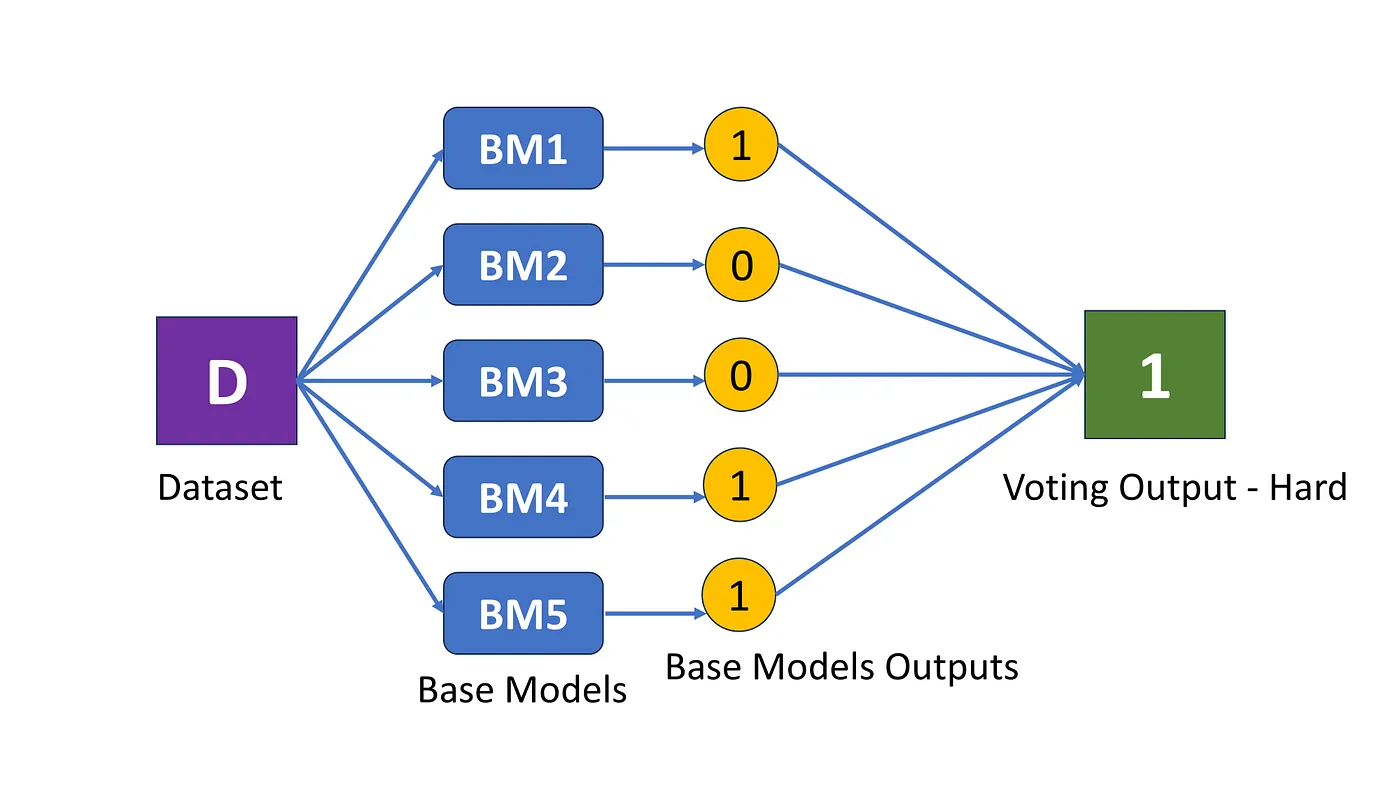

In [63]:
from sklearn.ensemble import VotingClassifier

In [64]:
inputs_vot = data_knn[['contract_over_request_cnt_9','online_pos_9_count','MonthsEmployed','DTIRatio',
                       'Region','MaritalStatus','Education','EmploymentType','LoanPurpose']]

X_train, X_test, y_train, y_test = train_test_split(inputs_vot, output, test_size=0.3, random_state=42)

In [65]:
lr_model_vot = LogisticRegression()

In [66]:
# RF

from sklearn.model_selection import cross_val_score
import optuna

def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 10, 500), 
    'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt']),  
    'max_depth': trial.suggest_int('max_depth', 10, 50),  
    'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),  
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),  
}

    rf_clf = RandomForestClassifier(**param)

    roc = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model_vot = RandomForestClassifier(**best_params)

[I 2026-04-03 08:38:52,114] A new study created in memory with name: no-name-9e018b3b-3403-4fc9-9d2d-b23fb8767a60
[I 2026-04-03 08:39:00,403] Trial 0 finished with value: 0.662952207842612 and parameters: {'n_estimators': 29, 'max_features': 'log2', 'max_depth': 34, 'min_samples_split': 168, 'min_samples_leaf': 44}. Best is trial 0 with value: 0.662952207842612.
[I 2026-04-03 08:39:05,249] Trial 1 finished with value: 0.672075335958475 and parameters: {'n_estimators': 254, 'max_features': 'log2', 'max_depth': 46, 'min_samples_split': 159, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.672075335958475.
[I 2026-04-03 08:39:07,093] Trial 2 finished with value: 0.6730065064253931 and parameters: {'n_estimators': 99, 'max_features': 'log2', 'max_depth': 25, 'min_samples_split': 151, 'min_samples_leaf': 31}. Best is trial 2 with value: 0.6730065064253931.
[I 2026-04-03 08:39:07,867] Trial 3 finished with value: 0.674605919375844 and parameters: {'n_estimators': 39, 'max_features': 'lo

Best trial:
  Value: 0.678
  Params:  {'n_estimators': 122, 'max_features': 'sqrt', 'max_depth': 45, 'min_samples_split': 100, 'min_samples_leaf': 46}


In [70]:
# XGBoost

def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_clf = XGBClassifier(**param)
    auc = cross_val_score(xgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model_vot = XGBClassifier(**best_params)

[I 2026-04-03 09:29:24,711] A new study created in memory with name: no-name-f45090b7-8351-4be0-b039-9778ba1e0f00
[I 2026-04-03 09:29:26,169] Trial 0 finished with value: 0.6687883741947728 and parameters: {'n_estimators': 827, 'learning_rate': 0.2359231684695511, 'max_depth': 8, 'subsample': 0.8751410444608134, 'colsample_bytree': 0.9296673823169274, 'gamma': 6}. Best is trial 0 with value: 0.6687883741947728.
[I 2026-04-03 09:29:26,353] Trial 1 finished with value: 0.6808278533781161 and parameters: {'n_estimators': 32, 'learning_rate': 0.033449658796268496, 'max_depth': 7, 'subsample': 0.7683225082921439, 'colsample_bytree': 0.6363097066594252, 'gamma': 9}. Best is trial 1 with value: 0.6808278533781161.
[I 2026-04-03 09:29:26,711] Trial 2 finished with value: 0.678509912859805 and parameters: {'n_estimators': 185, 'learning_rate': 0.030677572045637713, 'max_depth': 5, 'subsample': 0.7805660665645908, 'colsample_bytree': 0.6091937767215149, 'gamma': 9}. Best is trial 1 with value: 0

Best trial:
  Value: 0.681
  Params:  {'n_estimators': 984, 'learning_rate': 0.016914004516927972, 'max_depth': 3, 'subsample': 0.6740107493675108, 'colsample_bytree': 0.6053155135352972, 'gamma': 7}


In [67]:
# Catboost

def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), 
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['Logloss'])
    }

    cb_clf = CatBoostClassifier(**param)

    auc = cross_val_score(cb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=1)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model_vot = CatBoostClassifier(**best_params)

[I 2026-04-03 08:47:57,572] A new study created in memory with name: no-name-5cf3b04a-020d-4d52-8998-ec73137fbfaa
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\4118186931.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\4118186931.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10),
[I 2026-04-03 08:48:09,358] Trial 0 finished with value: 0.6300234786847629 and parameters: {'iterations': 183, 'learning_rate': 0.14221150403828323, 'depth': 10, 'l2_leaf_reg': 1.3270638831301804, 'l

Best trial:
  Value: 0.630
  Params:  {'iterations': 183, 'learning_rate': 0.14221150403828323, 'depth': 10, 'l2_leaf_reg': 1.3270638831301804, 'loss_function': 'Logloss'}


In [74]:


def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_clf = LGBMClassifier(**param)

    auc = cross_val_score(lgb_clf, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgbm_model_vot = LGBMClassifier(**best_params)

[I 2026-04-03 09:31:07,672] A new study created in memory with name: no-name-f779f41c-6a2f-44f3-a740-136ba0ccf53a
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\3599205400.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-04-03 09:31:10,948] Trial 0 finished with value: 0.63862179738889 and parameters: {'n_estimators': 871, 'learning_rate': 0.015250891512791038, 'max_depth': 6, 'num_leaves': 42}. Best is trial 0 with value: 0.63862179738889.
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_7608\3599205400.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_lo

Best trial:
  Value: 0.639
  Params:  {'n_estimators': 871, 'learning_rate': 0.015250891512791038, 'max_depth': 6, 'num_leaves': 42}


In [75]:
voting_clf_hard = VotingClassifier(
    estimators=[
        ('lr', lr_model_vot),
        ('rf', best_rf_model_vot),
        ('xgb', best_xgb_model_vot),
        ('cat', best_cb_model_vot),
        ('lgbm',best_lgbm_model_vot)
    ],
    voting='hard' 
)

In [76]:
from sklearn.metrics import classification_report

def train_and_evaluate_model_voting_hard(model_name, model, X_train, y_train, X_test, y_test):
    try:
        print(f"\nTraining {model_name}...")
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Classification reports as dicts
        train_report_dict = classification_report(y_train, y_train_pred, output_dict=True)
        test_report_dict = classification_report(y_test, y_test_pred, output_dict=True)

        # Convert to DataFrames
        train_report_df = pd.DataFrame(train_report_dict).transpose()
        test_report_df = pd.DataFrame(test_report_dict).transpose()

        # Add model info
        train_report_df["Dataset"] = "Train"
        train_report_df["Model"] = model_name

        test_report_df["Dataset"] = "Test"
        test_report_df["Model"] = model_name

        # Combine into one dataframe
        final_df = pd.concat([train_report_df, test_report_df], axis=0)

        return final_df

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None


In [77]:
train_and_evaluate_model_voting_hard('Voting model', voting_clf_hard, X_train, y_train, X_test, y_test)


Training Voting model...


C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0:	learn: 0.5856469	total: 7.58ms	remaining: 1.38s
1:	learn: 0.5032649	total: 27.9ms	remaining: 2.52s
2:	learn: 0.4426128	total: 49.3ms	remaining: 2.96s
3:	learn: 0.3911549	total: 71.3ms	remaining: 3.19s
4:	learn: 0.3469464	total: 76.1ms	remaining: 2.71s
5:	learn: 0.3154149	total: 96.6ms	remaining: 2.85s
6:	learn: 0.2874153	total: 116ms	remaining: 2.92s
7:	learn: 0.2636155	total: 136ms	remaining: 2.97s
8:	learn: 0.2456592	total: 155ms	remaining: 3s
9:	learn: 0.2312867	total: 176ms	remaining: 3.05s
10:	learn: 0.2192426	total: 202ms	remaining: 3.16s
11:	learn: 0.2058423	total: 205ms	remaining: 2.92s
12:	learn: 0.1960703	total: 223ms	remaining: 2.91s
13:	learn: 0.1876042	total: 255ms	remaining: 3.08s
14:	learn: 0.1807550	total: 273ms	remaining: 3.06s
15:	learn: 0.1743758	total: 290ms	remaining: 3.03s
16:	learn: 0.1686518	total: 307ms	remaining: 3s
17:	learn: 0.1637744	total: 325ms	remaining: 2.98s
18:	learn: 0.1598185	total: 344ms	remaining: 2.97s
19:	learn: 0.1557356	total: 361ms	remaini

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

,precision,recall,f1-score,support,Dataset,Model
0,0.963436,1.000000,0.981377,8906.000000,Train,Voting model
1,0.000000,0.000000,0.000000,338.000000,Train,Voting model
accuracy,0.963436,0.963436,0.963436,0.963436,Train,Voting model
macro avg,0.481718,0.500000,0.490689,9244.000000,Train,Voting model
weighted avg,0.928208,0.963436,0.945494,9244.000000,Train,Voting model
0,0.963655,1.000000,0.981491,3818.000000,Test,Voting model
1,0.000000,0.000000,0.000000,144.000000,Test,Voting model
accuracy,0.963655,0.963655,0.963655,0.963655,Test,Voting model
macro avg,0.481827,0.500000,0.490746,3962.000000,Test,Voting model
weighted avg,0.928630,0.963655,0.945818,3962.000000,Test,Voting model


# Voting Classifier - Soft

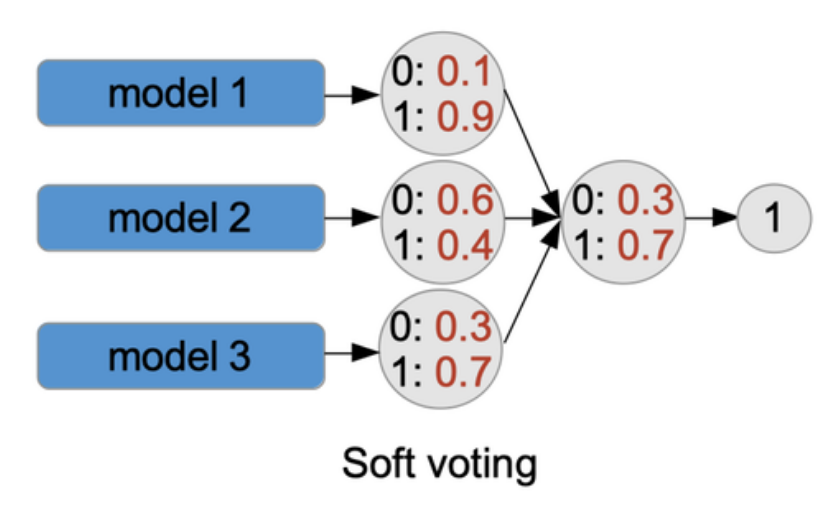

##  Class 0: (0.1 + 0.6 + 0.3) / 3 = 0.3

##  Class 1: (0.9 + 0.4 + 0.7) / 3 = 0.7

In [78]:
voting_clf_soft = VotingClassifier(
    estimators=[
        ('lr', lr_model_vot),
        ('rf', best_rf_model_vot),
        ('xgb', best_xgb_model_vot),
        ('cat', best_cb_model_vot),
        ('lgbm',best_lgbm_model_vot)
    ],
    voting='soft' 
)

train_and_evaluate_model('Voting model', voting_clf_soft, X_train, y_train, X_test, y_test)

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0:	learn: 0.5856469	total: 6.17ms	remaining: 1.12s
1:	learn: 0.5032649	total: 25.4ms	remaining: 2.3s
2:	learn: 0.4426128	total: 44.4ms	remaining: 2.66s
3:	learn: 0.3911549	total: 63.2ms	remaining: 2.83s
4:	learn: 0.3469464	total: 67.1ms	remaining: 2.39s
5:	learn: 0.3154149	total: 84.3ms	remaining: 2.49s
6:	learn: 0.2874153	total: 101ms	remaining: 2.55s
7:	learn: 0.2636155	total: 119ms	remaining: 2.6s
8:	learn: 0.2456592	total: 136ms	remaining: 2.63s
9:	learn: 0.2312867	total: 153ms	remaining: 2.65s
10:	learn: 0.2192426	total: 170ms	remaining: 2.66s
11:	learn: 0.2058423	total: 173ms	remaining: 2.46s
12:	learn: 0.1960703	total: 190ms	remaining: 2.49s
13:	learn: 0.1876042	total: 207ms	remaining: 2.5s
14:	learn: 0.1807550	total: 227ms	remaining: 2.54s
15:	learn: 0.1743758	total: 252ms	remaining: 2.63s
16:	learn: 0.1686518	total: 270ms	remaining: 2.63s
17:	learn: 0.1637744	total: 287ms	remaining: 2.63s
18:	learn: 0.1598185	total: 304ms	remaining: 2.63s
19:	learn: 0.1557356	total: 322ms	rema

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Model Performance for Voting model
Train Gini prob is 99.45040707879933
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8906
           1       0.00      0.00      0.00       338

    accuracy                           0.96      9244
   macro avg       0.48      0.50      0.49      9244
weighted avg       0.93      0.96      0.95      9244

[[8906    0]
 [ 338    0]]
Model Performance for Voting model
Test Gini prob is 29.08372620918458
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3818
           1       0.00      0.00      0.00       144

    accuracy                           0.96      3962
   macro avg       0.48      0.50      0.49      3962
weighted avg       0.93      0.96      0.95      3962

[[3818    0]
 [ 144    0]]


C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

[0.9945040707879933, 0.2908372620918458]

# Stacking Classifier

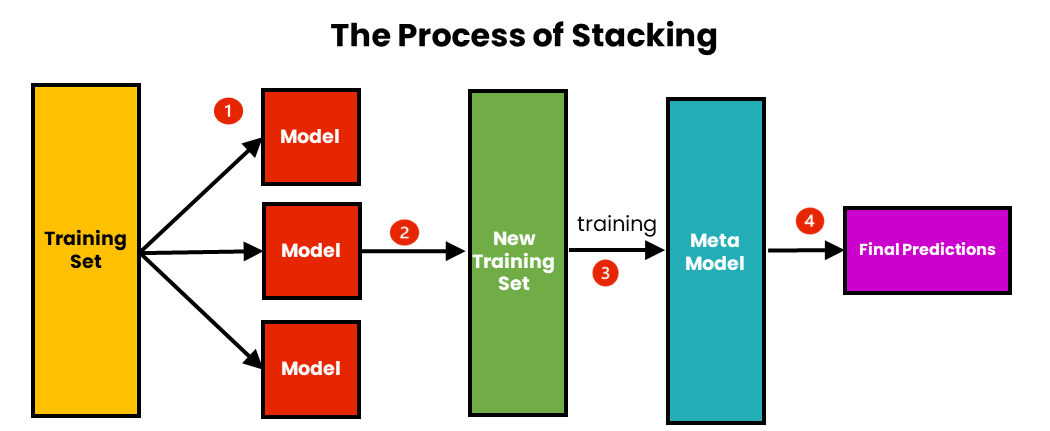

In [81]:
from sklearn.ensemble import StackingClassifier

In [82]:
estimators = [
    ('rf', best_rf_model_vot),
    ('xgb', best_xgb_model_vot),
    ('cat', best_cb_model_vot),
    ('lgbm',best_lgbm_model_vot)
]

estimators

[('rf',
  RandomForestClassifier(max_depth=45, min_samples_leaf=46, min_samples_split=100,
                         n_estimators=122)),
 ('xgb',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=0.6053155135352972, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=7, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.016914004516927972,
                max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=3, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=984, n_jobs=None,
                num_parallel_tree=None, ...)),
 ('cat',
  CatBoostClassifier(d

In [86]:
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=lr_model_vot,
    passthrough=True,   # if True, raw features are also passed to final estimator
    cv=5,                
    stack_method='predict_proba'  # ensures probabilities are passed
)

stack_clf

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",True
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",122
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",45
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samp

In [87]:
train_and_evaluate_model('Stacking model', stack_clf, X_train, y_train, X_test, y_test)

0:	learn: 0.5856469	total: 6.42ms	remaining: 1.17s
1:	learn: 0.5032649	total: 24.2ms	remaining: 2.19s
2:	learn: 0.4426128	total: 42.6ms	remaining: 2.55s
3:	learn: 0.3911549	total: 62.1ms	remaining: 2.78s
4:	learn: 0.3469464	total: 66.1ms	remaining: 2.35s
5:	learn: 0.3154149	total: 83.3ms	remaining: 2.46s
6:	learn: 0.2874153	total: 100ms	remaining: 2.52s
7:	learn: 0.2636155	total: 117ms	remaining: 2.57s
8:	learn: 0.2456592	total: 134ms	remaining: 2.6s
9:	learn: 0.2312867	total: 152ms	remaining: 2.62s
10:	learn: 0.2192426	total: 169ms	remaining: 2.64s
11:	learn: 0.2058423	total: 172ms	remaining: 2.44s
12:	learn: 0.1960703	total: 189ms	remaining: 2.47s
13:	learn: 0.1876042	total: 206ms	remaining: 2.49s
14:	learn: 0.1807550	total: 224ms	remaining: 2.51s
15:	learn: 0.1743758	total: 255ms	remaining: 2.66s
16:	learn: 0.1686518	total: 273ms	remaining: 2.67s
17:	learn: 0.1637744	total: 290ms	remaining: 2.66s
18:	learn: 0.1598185	total: 309ms	remaining: 2.67s
19:	learn: 0.1557356	total: 326ms	re

C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\skl

Model Performance for Stacking model
Train Gini prob is 38.71294798932175
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8906
           1       0.00      0.00      0.00       338

    accuracy                           0.96      9244
   macro avg       0.48      0.50      0.49      9244
weighted avg       0.93      0.96      0.95      9244

[[8906    0]
 [ 338    0]]
Model Performance for Stacking model
Test Gini prob is 25.53256504277983
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3818
           1       0.00      0.00      0.00       144

    accuracy                           0.96      3962
   macro avg       0.48      0.50      0.49      3962
weighted avg       0.93      0.96      0.95      3962

[[3818    0]
 [ 144    0]]


C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TOSHIBA\miniconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

[0.38712947989321744, 0.2553256504277983]